Netflix Content Analysis and Movie/TV Show Classification using Machine Learning

In [1]:
%pip install seaborn

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
warnings.filterwarnings('ignore')
os.makedirs('charts', exist_ok=True)
print("Charts folder ready!")

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (accuracy_score,precision_score,recall_score,f1_score,confusion_matrix,classification_report)

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
print("All libraries imported successfully!")

ModuleNotFoundError: No module named 'seaborn'

DataSet Reading And Understanding

In [ ]:
df = pd.read_csv('netflix_titles.csv')

print("Shape of dataset:", df.shape)
print("\nColumn names:")
print(df.columns.tolist())
print("\nFirst 5 rows:")
print(df.head())
print("\nContent type count:")
print(df['type'].value_counts())
print("=== Dataset Shape ===")
print(df.shape)
print("\n=== Data Types of Each Column ===")
print(df.dtypes)
print("\n=== Basic Statistics ===")
print(df.describe())

Shape of dataset: (8807, 12)

Column names:
['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added', 'release_year', 'rating', 'duration', 'listed_in', 'description']

First 5 rows:
  show_id     type                  title         director  \
0      s1    Movie   Dick Johnson Is Dead  Kirsten Johnson   
1      s2  TV Show          Blood & Water              NaN   
2      s3  TV Show              Ganglands  Julien Leclercq   
3      s4  TV Show  Jailbirds New Orleans              NaN   
4      s5  TV Show           Kota Factory              NaN   

                                                cast        country  \
0                                                NaN  United States   
1  Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...   South Africa   
2  Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...            NaN   
3                                                NaN            NaN   
4  Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...          India   

 

Data Cleaning

In [ ]:
print("\n=== Missing Values in Each Column ===")
print(df.isnull().sum())

print("\n=== Missing Values in Percentage ===")
print(round(df.isnull().sum() / len(df) * 100, 2))

df['director'] = df['director'].fillna('Unknown')
df['cast'] = df['cast'].fillna('Unknown')
df['country'] = df['country'].fillna('Unknown')
df['rating'] = df['rating'].fillna('Unknown')
df['duration'] = df['duration'].fillna('Unknown')

print("Step 1 done - Missing values filled")

df.dropna(subset=['date_added'], inplace=True)
print("Step 2 done - Dropped rows with missing date_added")

df['date_added'] = df['date_added'].str.strip()
print("Step 3 done - Stripped spaces from date_added")

df['date_added'] = pd.to_datetime(df['date_added'])
print("Step 4 done - Converted date_added to datetime")

df['year_added'] = df['date_added'].dt.year
df['month_added'] = df['date_added'].dt.month
print("Step 5 done - Extracted year_added and month_added")

before = len(df)
df.drop_duplicates(inplace=True)
after = len(df)
print(f"Step 6 done - Removed {before - after} duplicate rows")

print("\n=== Missing Values After Cleaning ===")
print(df.isnull().sum())

print("\n=== New Columns Preview ===")
print(df[['title', 'date_added', 'year_added', 'month_added']].head())


=== Missing Values in Each Column ===
show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

=== Missing Values in Percentage ===
show_id          0.00
type             0.00
title            0.00
director        29.91
cast             9.37
country          9.44
date_added       0.11
release_year     0.00
rating           0.05
duration         0.03
listed_in        0.00
description      0.00
dtype: float64
Step 1 done - Missing values filled
Step 2 done - Dropped rows with missing date_added
Step 3 done - Stripped spaces from date_added
Step 4 done - Converted date_added to datetime
Step 5 done - Extracted year_added and month_added
Step 6 done - Removed 0 duplicate rows

=== Missing Values After Cleaning ===
show_id         0
type            0
title           0
director        

EXPLORATORY DATA ANALYSIS

Q1: Movies vs TV Shows

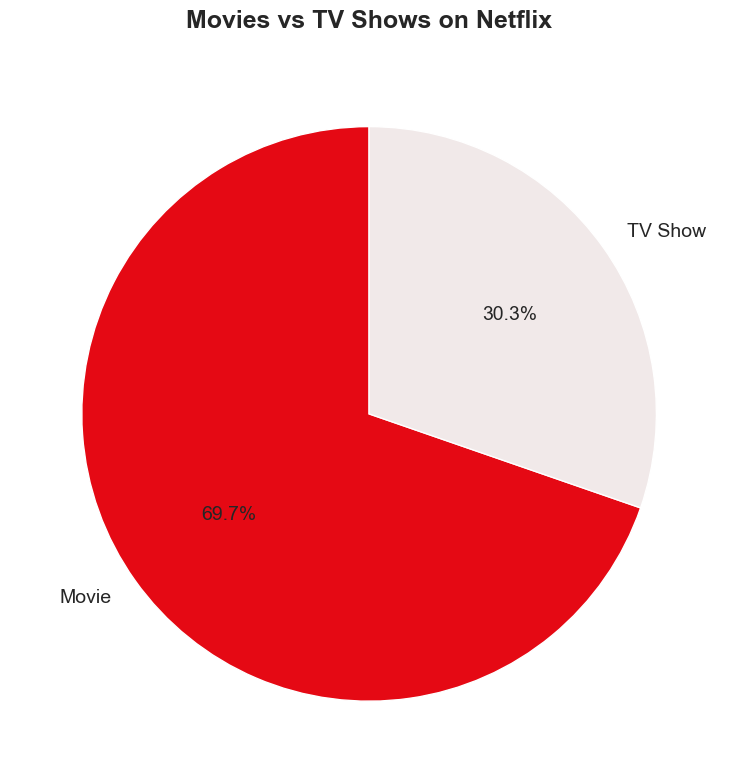

Movies: 6131
TV Shows: 2666


In [ ]:
type_counts = df['type'].value_counts()

plt.figure(figsize=(8, 8))
plt.pie(type_counts,labels=type_counts.index,autopct='%1.1f%%',colors=['#E50914', "#F1E9E9"],startangle=90,textprops={'fontsize': 14})
plt.title('Movies vs TV Shows on Netflix', fontsize=18, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('charts/q1_movies_vs_tvshows.png', dpi=150)
plt.show()
print("Movies:", type_counts['Movie'])
print("TV Shows:", type_counts['TV Show'])

Q2: Top 10 Countries by Content

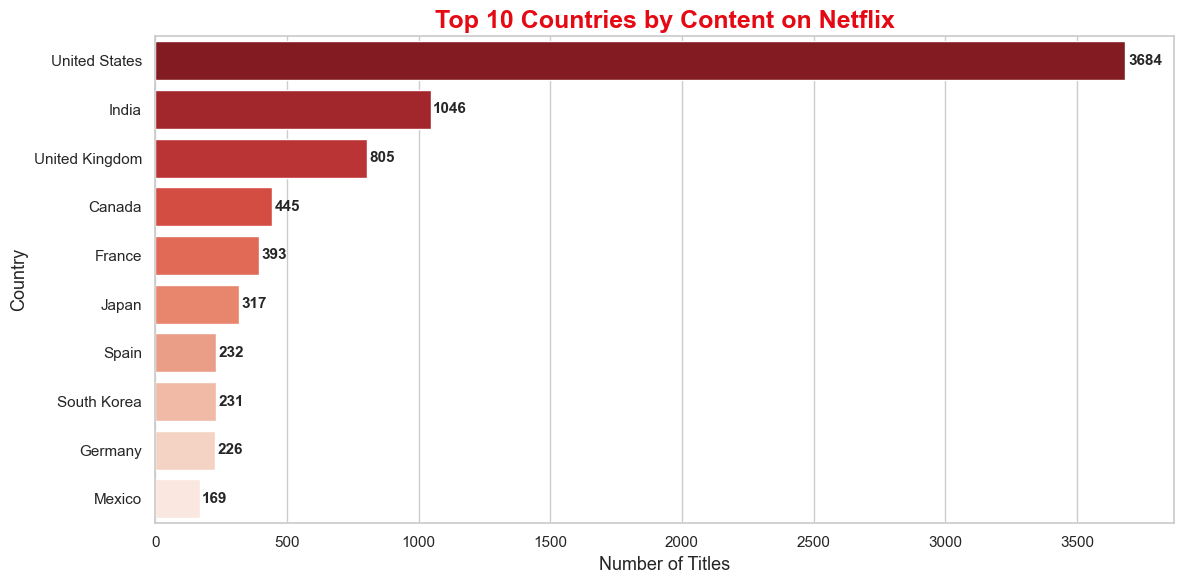


=== Top 10 Countries ===
country
United States     3684
India             1046
United Kingdom     805
Canada             445
France             393
Japan              317
Spain              232
South Korea        231
Germany            226
Mexico             169
Name: count, dtype: int64


In [ ]:
country_data = df['country'].str.split(',').explode().str.strip()
country_data = country_data[country_data != 'Unknown']
top_countries = country_data.value_counts().head(10)
plt.figure(figsize=(12, 6))
bars = sns.barplot(x=top_countries.values,y=top_countries.index,palette='Reds_r')

for i, v in enumerate(top_countries.values):
    bars.text(v + 10, i, str(v), va='center', fontsize=11, fontweight='bold')

plt.title('Top 10 Countries by Content on Netflix', fontsize=18, fontweight='bold', color='#E50914')
plt.xlabel('Number of Titles', fontsize=13)
plt.ylabel('Country', fontsize=13)
plt.tight_layout()
plt.savefig('charts/q2_top_countries.png', dpi=150)
plt.show()

print("\n=== Top 10 Countries ===")
print(top_countries)

Q3: Content Added Per Year

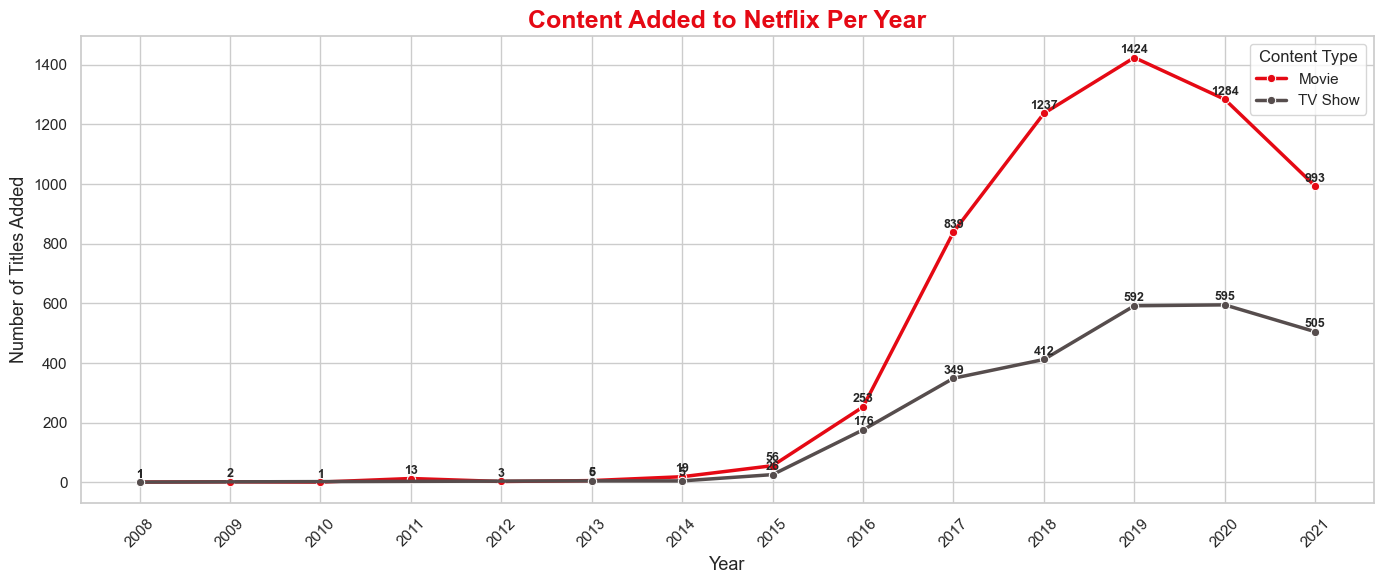


=== Content Added Per Year ===
type         Movie  TV Show
year_added                 
2008           1.0      1.0
2009           2.0      NaN
2010           1.0      NaN
2011          13.0      NaN
2012           3.0      NaN
2013           6.0      5.0
2014          19.0      5.0
2015          56.0     26.0
2016         253.0    176.0
2017         839.0    349.0
2018        1237.0    412.0
2019        1424.0    592.0
2020        1284.0    595.0
2021         993.0    505.0


In [ ]:
yearly_content = df.groupby(['year_added', 'type']).size().reset_index(name='count')

plt.figure(figsize=(14, 6))
sns.lineplot(data=yearly_content,x='year_added',y='count',hue='type',marker='o',linewidth=2.5,palette={'Movie': '#E50914', 'TV Show': '#564d4d'})

for _, row in yearly_content.iterrows():
    plt.text(row['year_added'],row['count'] + 15,str(row['count']),ha='center',fontsize=9,fontweight='bold')

plt.title('Content Added to Netflix Per Year', fontsize=18, fontweight='bold', color='#E50914')
plt.xlabel('Year', fontsize=13)
plt.ylabel('Number of Titles Added', fontsize=13)
plt.xticks(yearly_content['year_added'].unique(), rotation=45)
plt.legend(title='Content Type', fontsize=11)
plt.tight_layout()
plt.savefig('charts/q3_content_per_year.png', dpi=150)
plt.show()

print("\n=== Content Added Per Year ===")
print(yearly_content.pivot(index='year_added', columns='type', values='count'))

Q4: Ratings Distribution

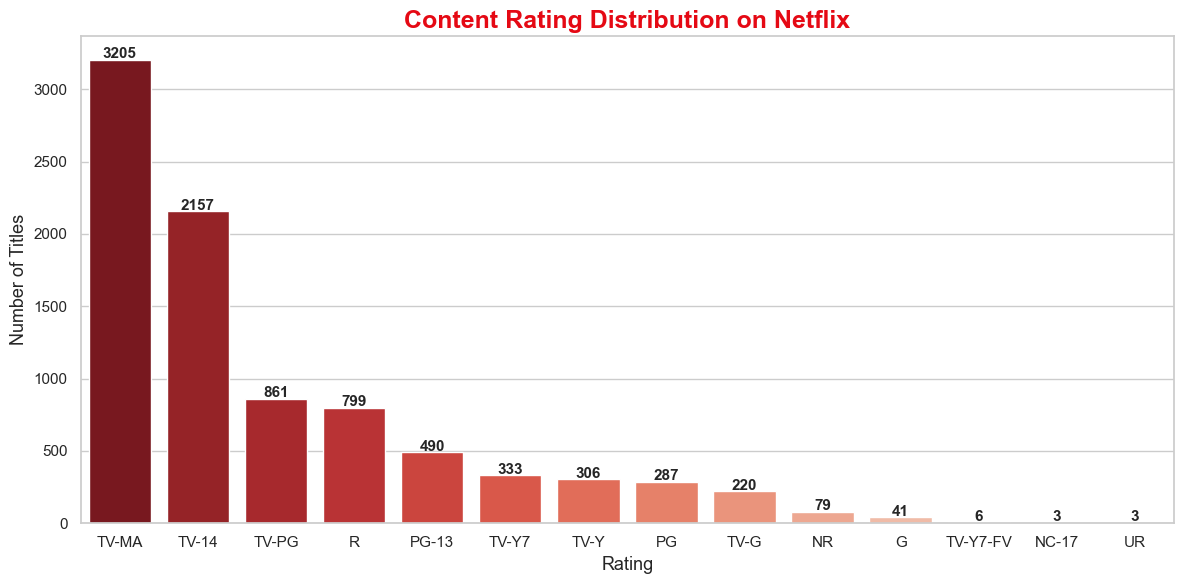


=== Rating Counts ===
rating
TV-MA       3205
TV-14       2157
TV-PG        861
R            799
PG-13        490
TV-Y7        333
TV-Y         306
PG           287
TV-G         220
NR            79
G             41
TV-Y7-FV       6
NC-17          3
UR             3
Name: count, dtype: int64


In [ ]:
valid_ratings = ['G', 'PG', 'PG-13', 'R', 'NC-17', 'NR', 'UR','TV-Y', 'TV-Y7', 'TV-Y7-FV', 'TV-G', 'TV-PG', 'TV-14', 'TV-MA']

rating_counts = df[df['rating'].isin(valid_ratings)]['rating'].value_counts()

plt.figure(figsize=(12, 6))
bars = sns.barplot(x=rating_counts.index,y=rating_counts.values,palette='Reds_r')

for i, v in enumerate(rating_counts.values):
    bars.text(i, v + 10, str(v), ha='center', fontsize=11, fontweight='bold')

plt.title('Content Rating Distribution on Netflix', fontsize=18, fontweight='bold', color='#E50914')
plt.xlabel('Rating', fontsize=13)
plt.ylabel('Number of Titles', fontsize=13)
plt.xticks(fontsize=11)
plt.tight_layout()
plt.savefig('charts/q4_ratings.png', dpi=150)
plt.show()

print("\n=== Rating Counts ===")
print(rating_counts)

Q5: Most Popular Genres

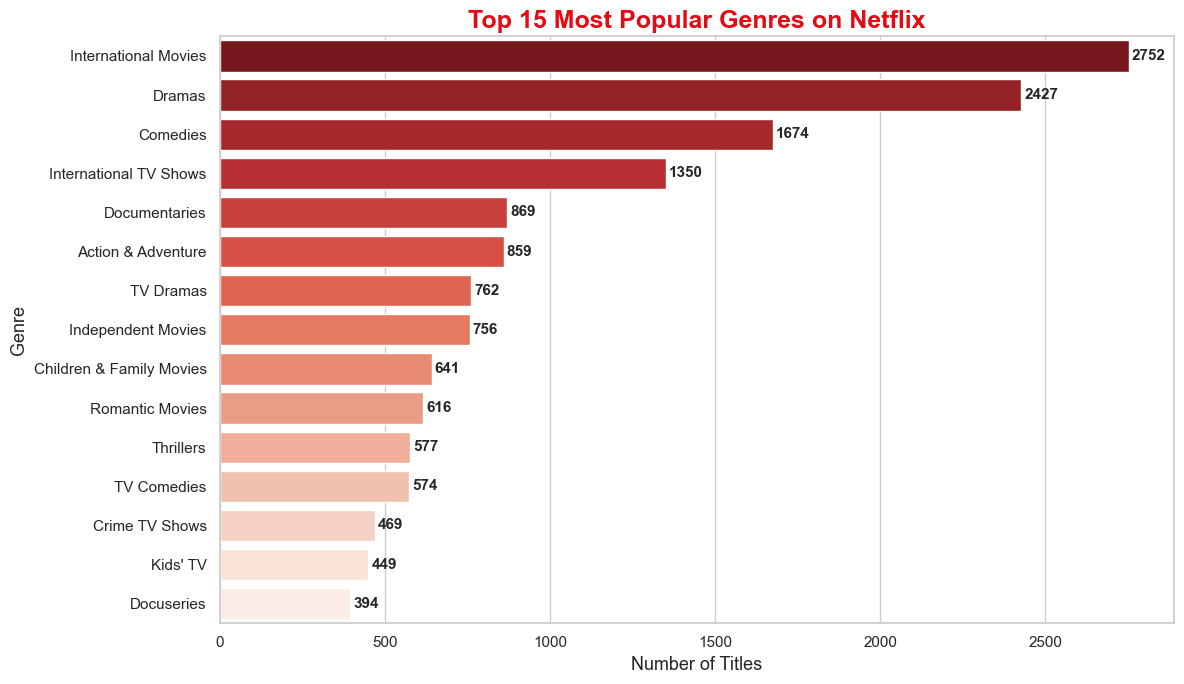


=== Top 15 Genres ===
listed_in
International Movies        2752
Dramas                      2427
Comedies                    1674
International TV Shows      1350
Documentaries                869
Action & Adventure           859
TV Dramas                    762
Independent Movies           756
Children & Family Movies     641
Romantic Movies              616
Thrillers                    577
TV Comedies                  574
Crime TV Shows               469
Kids' TV                     449
Docuseries                   394
Name: count, dtype: int64


In [ ]:
genre_data = df['listed_in'].str.split(',').explode().str.strip()

top_genres = genre_data.value_counts().head(15)

plt.figure(figsize=(12, 7))
bars = sns.barplot(x=top_genres.values,y=top_genres.index,palette='Reds_r')
for i, v in enumerate(top_genres.values):
    bars.text(v + 10, i, str(v), va='center', fontsize=11, fontweight='bold')

plt.title('Top 15 Most Popular Genres on Netflix', fontsize=18, fontweight='bold', color='#E50914')
plt.xlabel('Number of Titles', fontsize=13)
plt.ylabel('Genre', fontsize=13)
plt.tight_layout()
plt.savefig('charts/q5_genres.png', dpi=150)
plt.show()

print("\n=== Top 15 Genres ===")
print(top_genres)

Q6: Movie Duration Distribution

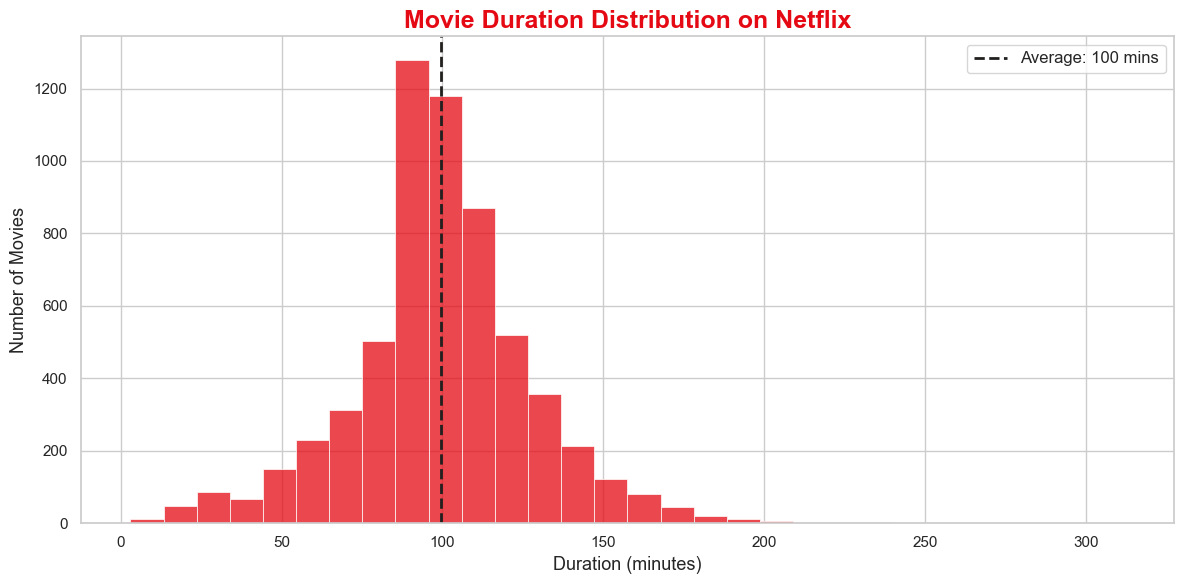


=== Movie Duration Stats ===
Average duration : 100 mins
Shortest movie   : 3 mins
Longest movie    : 312 mins
Most common range: 80 - 120 mins


In [ ]:
movies_df = df[df['type'] == 'Movie'].copy()

movies_df['duration_int'] = movies_df['duration'].str.extract('(\d+)').astype(float)

plt.figure(figsize=(12, 6))
sns.histplot(data=movies_df,x='duration_int',bins=30,color='#E50914',edgecolor='white',linewidth=0.5)

avg_duration = movies_df['duration_int'].mean()
plt.axvline(avg_duration,color='#221F1F',linestyle='--',linewidth=2,label=f'Average: {avg_duration:.0f} mins')

plt.title('Movie Duration Distribution on Netflix', fontsize=18, fontweight='bold', color='#E50914')
plt.xlabel('Duration (minutes)', fontsize=13)
plt.ylabel('Number of Movies', fontsize=13)
plt.legend(fontsize=12)
plt.tight_layout()
plt.savefig('charts/q6_movie_duration.png', dpi=150)
plt.show()

print("\n=== Movie Duration Stats ===")
print(f"Average duration : {movies_df['duration_int'].mean():.0f} mins")
print(f"Shortest movie   : {movies_df['duration_int'].min():.0f} mins")
print(f"Longest movie    : {movies_df['duration_int'].max():.0f} mins")
print(f"Most common range: 80 - 120 mins")

Q7: Content Added Per Month

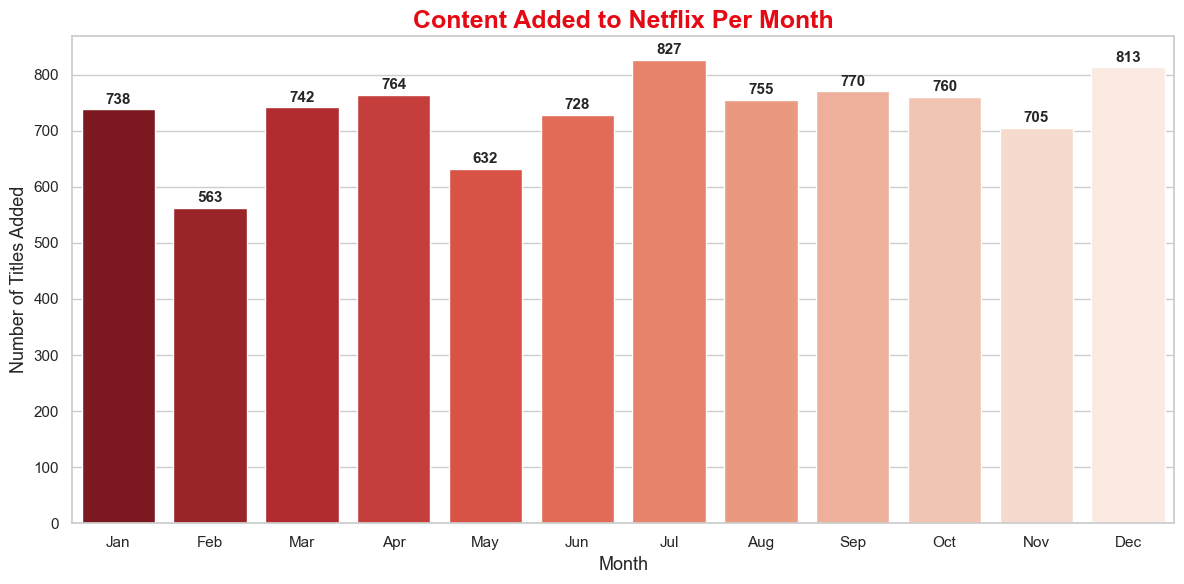


=== Content Added Per Month ===
Jan: 738
Feb: 563
Mar: 742
Apr: 764
May: 632
Jun: 728
Jul: 827
Aug: 755
Sep: 770
Oct: 760
Nov: 705
Dec: 813


In [ ]:
month_names = {1: 'Jan', 2: 'Feb', 3: 'Mar', 4: 'Apr', 5: 'May', 6: 'Jun', 7: 'Jul', 8: 'Aug', 9: 'Sep', 10: 'Oct', 11: 'Nov', 12: 'Dec'}

monthly_counts = df['month_added'].value_counts().sort_index()
monthly_counts.index = monthly_counts.index.map(month_names)

plt.figure(figsize=(12, 6))
bars = sns.barplot( x=monthly_counts.index, y=monthly_counts.values, palette='Reds_r')

for i, v in enumerate(monthly_counts.values):
    bars.text(i, v + 10, str(v), ha='center', fontsize=11, fontweight='bold')

plt.title('Content Added to Netflix Per Month', fontsize=18, fontweight='bold', color='#E50914')
plt.xlabel('Month', fontsize=13)
plt.ylabel('Number of Titles Added', fontsize=13)
plt.tight_layout()
plt.savefig('charts/q7_content_per_month.png', dpi=150)
plt.show()

print("\n=== Content Added Per Month ===")
for month, count in zip(monthly_counts.index, monthly_counts.values):
    print(f"{month}: {count}")

FEATURE ENGINEERING

In [ ]:
df['duration_int'] = df['duration'].str.extract('(\d+)').astype(float)
print("Step 1 done - Duration extracted as number")
print(df[['duration', 'duration_int']].head())

le_country = LabelEncoder()
le_rating = LabelEncoder()
df['country_encoded'] = le_country.fit_transform(df['country'])
df['rating_encoded'] = le_rating.fit_transform(df['rating'])
print("\nStep 2 done - Country and Rating encoded")
print(df[['country', 'country_encoded', 'rating', 'rating_encoded']].head())


le_type = LabelEncoder()
df['type_encoded'] = le_type.fit_transform(df['type'])
print("\nStep 3 done - Type encoded")
print(df[['type', 'type_encoded']].head())

X = df[['country_encoded', 'rating_encoded', 'duration_int', 'year_added', 'month_added', 'release_year']]
y = df['type_encoded']
print("\nStep 4 done - Features and target defined")
print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")
print(f"\nFeature columns: {X.columns.tolist()}")
print(f"Target: type_encoded (0=Movie, 1=TV Show)")


X_train, X_test, y_train, y_test = train_test_split(X, y,test_size=0.2,random_state=42)
print("\nStep 5 done - Data split into train and test")
print(f"Training samples : {X_train.shape[0]}")
print(f"Testing samples  : {X_test.shape[0]}")

Step 1 done - Duration extracted as number
    duration  duration_int
0     90 min          90.0
1  2 Seasons           2.0
2   1 Season           1.0
3   1 Season           1.0
4  2 Seasons           2.0

Step 2 done - Country and Rating encoded
         country  country_encoded rating  rating_encoded
0  United States              603  PG-13               7
1   South Africa              426  TV-MA              11
2        Unknown              736  TV-MA              11
3        Unknown              736  TV-MA              11
4          India              251  TV-MA              11

Step 3 done - Type encoded
      type  type_encoded
0    Movie             0
1  TV Show             1
2  TV Show             1
3  TV Show             1
4  TV Show             1

Step 4 done - Features and target defined
X shape: (8797, 6)
y shape: (8797,)

Feature columns: ['country_encoded', 'rating_encoded', 'duration_int', 'year_added', 'month_added', 'release_year']
Target: type_encoded (0=Movie, 1=TV S

MODEL TRAINING(RandomForestClassifier)

In [ ]:
model = RandomForestClassifier(n_estimators=100,max_depth=10,random_state=42)

print("Step 1 done - Model initialized")
print(f"Model: {model}")

print("\nStep 2 - Training the model...")
model.fit(X_train, y_train)
print("Step 2 done - Model trained successfully!")

y_pred = model.predict(X_test)
print("\nStep 3 done - Predictions made")
print(f"First 10 actual values    : {list(y_test[:10])}")
print(f"First 10 predicted values : {list(y_pred[:10])}")

print("\n=== Sample Predictions ===")
for actual, predicted in zip(list(y_test[:5]), list(y_pred[:5])):
    actual_label = le_type.inverse_transform([actual])[0]
    predicted_label = le_type.inverse_transform([predicted])[0]
    status = '✓ Correct' if actual == predicted else '✗ Wrong'
    print(f"Actual: {actual_label:10} | Predicted: {predicted_label:10} | {status}")

Step 1 done - Model initialized
Model: RandomForestClassifier(max_depth=10, random_state=42)

Step 2 - Training the model...
Step 2 done - Model trained successfully!

Step 3 done - Predictions made
First 10 actual values    : [1, 1, 1, 0, 1, 1, 0, 0, 0, 0]
First 10 predicted values : [np.int64(1), np.int64(1), np.int64(1), np.int64(0), np.int64(1), np.int64(1), np.int64(0), np.int64(0), np.int64(0), np.int64(0)]

=== Sample Predictions ===
Actual: TV Show    | Predicted: TV Show    | ✓ Correct
Actual: TV Show    | Predicted: TV Show    | ✓ Correct
Actual: TV Show    | Predicted: TV Show    | ✓ Correct
Actual: Movie      | Predicted: Movie      | ✓ Correct
Actual: TV Show    | Predicted: TV Show    | ✓ Correct


MODEL EVALUATION

 MODEL EVALUATION RESULTS
  Accuracy  : 99.83%
  Precision : 99.44%
  Recall    : 100.00%
  F1 Score  : 99.72%

=== Classification Report ===
              precision    recall  f1-score   support

       Movie       1.00      1.00      1.00      1229
     TV Show       0.99      1.00      1.00       531

    accuracy                           1.00      1760
   macro avg       1.00      1.00      1.00      1760
weighted avg       1.00      1.00      1.00      1760



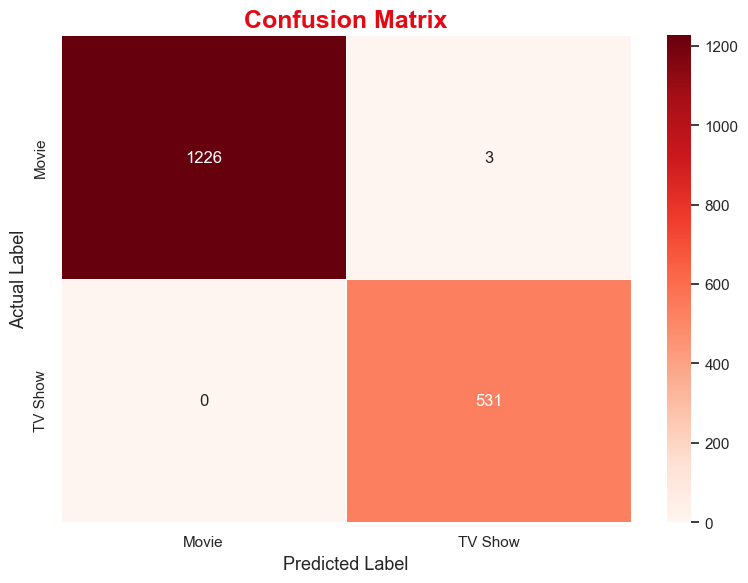

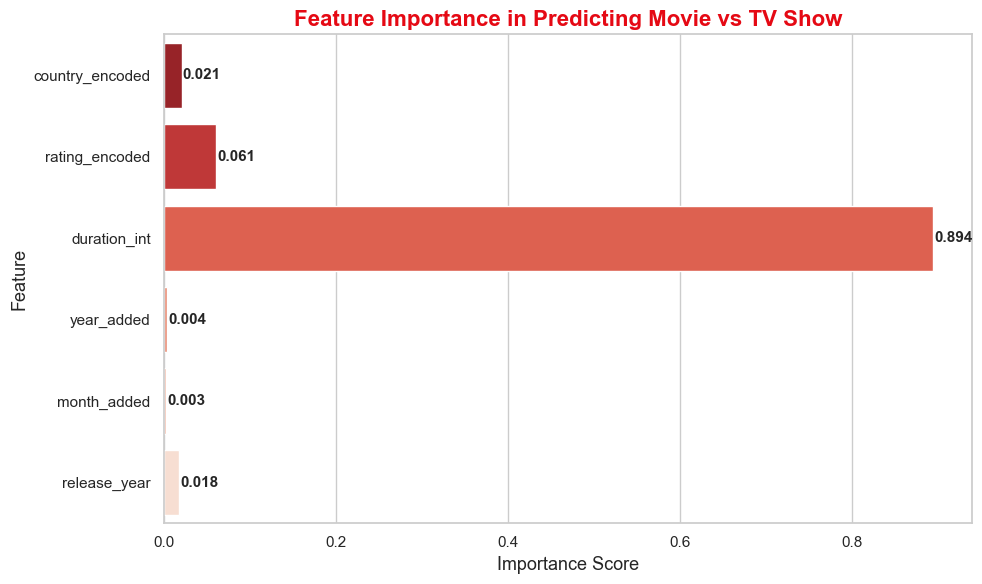


=== Feature Importance ===
duration_int         : 0.8940
rating_encoded       : 0.0607
country_encoded      : 0.0207
release_year         : 0.0179
year_added           : 0.0039
month_added          : 0.0028

           PROJECT SUMMARY
  Total titles analysed : 8797
  Movies                : 6131
  TV Shows              : 2666
  Features used         : 6
  Training samples      : 7037
  Testing samples       : 1760
  Model accuracy        : 99.83%

✓ END OF PROJECT!


In [ ]:
accuracy  = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall    = recall_score(y_test, y_pred)
f1        = f1_score(y_test, y_pred)

print("=" * 45)
print(" MODEL EVALUATION RESULTS")
print("=" * 45)
print(f"  Accuracy  : {accuracy  * 100:.2f}%")
print(f"  Precision : {precision * 100:.2f}%")
print(f"  Recall    : {recall    * 100:.2f}%")
print(f"  F1 Score  : {f1        * 100:.2f}%")
print("=" * 45)

print("\n=== Classification Report ===")
print(classification_report(y_test, y_pred,target_names=['Movie', 'TV Show']))

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm,annot=True,fmt='d',cmap='Reds',xticklabels=['Movie', 'TV Show'],yticklabels=['Movie', 'TV Show'],linewidths=0.5,linecolor='white')
plt.title('Confusion Matrix', fontsize=18, fontweight='bold', color='#E50914')
plt.xlabel('Predicted Label', fontsize=13)
plt.ylabel('Actual Label', fontsize=13)
plt.tight_layout()
plt.savefig('charts/q8_confusion_matrix.png', dpi=150)
plt.show()

feature_names = X.columns.tolist()
importances = model.feature_importances_

plt.figure(figsize=(10, 6))
bars = sns.barplot( x=importances,y=feature_names,palette='Reds_r')

for i, v in enumerate(importances):
    bars.text(v + 0.001, i, f'{v:.3f}', va='center', fontsize=11, fontweight='bold')

plt.title('Feature Importance in Predicting Movie vs TV Show',fontsize=16, fontweight='bold', color='#E50914')
plt.xlabel('Importance Score', fontsize=13)
plt.ylabel('Feature', fontsize=13)
plt.tight_layout()
plt.savefig('charts/q9_feature_importance.png', dpi=150)
plt.show()

print("\n=== Feature Importance ===")
for name, score in sorted(zip(feature_names, importances),
        key=lambda x: x[1], reverse=True):
    print(f"{name:20} : {score:.4f}")

print("\n" + "=" * 45)
print("           PROJECT SUMMARY")
print("=" * 45)
print(f"  Total titles analysed : {len(df)}")
print(f"  Movies                : {len(df[df['type'] == 'Movie'])}")
print(f"  TV Shows              : {len(df[df['type'] == 'TV Show'])}")
print(f"  Features used         : {len(feature_names)}")
print(f"  Training samples      : {X_train.shape[0]}")
print(f"  Testing samples       : {X_test.shape[0]}")
print(f"  Model accuracy        : {accuracy * 100:.2f}%")
print("=" * 45)
print("\n✓ END OF PROJECT!")